### **ML PROJEKAT ASJA OSMIC**

Priprema podataka, modeliranje i predikcija ocjena studenata koristenjem sljedecih metoda:


*   Linearna i polinomijalna regresija
*   Multinomijalna logisticka regresija (klasifikacija)
*   Neuronske mreze (klasifikacija)



### 1. Priprema podataka
*   Ucitavanje DataSet sa odabrane URL lokacije
*   Statisticka analiza DataSeta
*   Komentar 1a
*   Podjela DataFrame na trening i test podatke
*   Odredjivanje korelacije izmedju izlaznih (target) varijabli (labela) i ulaznih znacajki (features, regresijske varijable)
*   Odredjivanje vaznosti i komentiranje vaznosti znacajki
*   Komentar 1b




In [ ]:
#Ucitavanje modula
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
#Ucitavanje DataSeta sa odabranog URL na google drive (data set mora biti prethodno shared)
#Uputstvo: Extract the file ID from the shared link, which is located between /d/ and /view in the URL
#After you have the file ID, you can reformat the link as follows:
#"https://drive.google.com/uc?id=YOUR_FILE_ID/filename.csv".
try:
    !wget "https://drive.google.com/uc?id=1eIfpwWXcFxcDF8LYCgbyP2Tp3XAA7FsQ" -O "data_tema_1.csv"
    data = pd.read_csv("data_tema_1.csv")
except Exception as e:
     print(f"An error occurred: {e}")

--2025-09-18 12:04:36--  https://drive.google.com/uc?id=1eIfpwWXcFxcDF8LYCgbyP2Tp3XAA7FsQ
Resolving drive.google.com (drive.google.com)... 142.251.107.101, 142.251.107.100, 142.251.107.138, ...
Connecting to drive.google.com (drive.google.com)|142.251.107.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eIfpwWXcFxcDF8LYCgbyP2Tp3XAA7FsQ [following]
--2025-09-18 12:04:36--  https://drive.usercontent.google.com/download?id=1eIfpwWXcFxcDF8LYCgbyP2Tp3XAA7FsQ
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.26.132, 2607:f8b0:400c:c04::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.26.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 166901 (163K) [application/octet-stream]
Saving to: ‘data_tema_1.csv’

data_tema_1.csv     100%[===================>] 162.99K  --.-KB/s    in 0.002s  

2025-09-18 12:04:37 (73.2 MB/

In [ ]:
#Statisticka analiza DataSeta
#print(type(data))                                                          #stampanje podataka o tipu varijable data
print(data.describe())                                                      #statisticki pokazatelji dataseta
print(data.info())                                                         #informacije o tipu kolona
print(data.head(10))                                                        #stampanje prvih 10 redova varijable data



         StudentID          Age       Gender    Ethnicity  ParentalEducation  \
count  2392.000000  2392.000000  2392.000000  2392.000000        2392.000000   
mean   2196.500000    16.468645     0.510870     0.877508           1.746237   
std     690.655244     1.123798     0.499986     1.028476           1.000411   
min    1001.000000    15.000000     0.000000     0.000000           0.000000   
25%    1598.750000    15.000000     0.000000     0.000000           1.000000   
50%    2196.500000    16.000000     1.000000     0.000000           2.000000   
75%    2794.250000    17.000000     1.000000     2.000000           2.000000   
max    3392.000000    18.000000     1.000000     3.000000           4.000000   

       StudyTimeWeekly     Absences     Tutoring  ParentalSupport  \
count      2392.000000  2392.000000  2392.000000      2392.000000   
mean          9.771992    14.541388     0.301421         2.122074   
std           5.652774     8.467417     0.458971         1.122813   
min

In [ ]:
def funkcija_map0(x):
    return x.map({0:"bijelac",1:"afroamerikanac",2:"azijac",3:"ostalo"})
kolona1 = ["Ethnicity"]
data[kolona1] = data[kolona1].apply(funkcija_map0)
data.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,bijelac,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,bijelac,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,azijac,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,bijelac,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,bijelac,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [ ]:
#one-hot encoding
status = pd.get_dummies(data["Ethnicity"],drop_first=False)
data = pd.concat([data,status],axis=1)
data.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,afroamerikanac,azijac,bijelac,ostalo
0,1001,17,1,bijelac,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0,False,False,True,False
1,1002,18,0,bijelac,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0,False,False,True,False
2,1003,15,0,azijac,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0,False,True,False,False
3,1004,17,1,bijelac,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0,False,False,True,False
4,1005,17,1,bijelac,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0,False,False,True,False


In [ ]:
def funkcija_map1(x):
    return x.map({True:1,False:0})
kolona1 = ["afroamerikanac","azijac","bijelac","ostalo"]
data[kolona1] = data[kolona1].apply(funkcija_map1)
data.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,afroamerikanac,azijac,bijelac,ostalo
0,1001,17,1,bijelac,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0,0,0,1,0
1,1002,18,0,bijelac,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0,0,0,1,0
2,1003,15,0,azijac,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0,0,1,0,0
3,1004,17,1,bijelac,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0,0,0,1,0
4,1005,17,1,bijelac,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0,0,0,1,0


In [ ]:
data.drop(['Ethnicity'],axis=1,inplace=True)
data.head()

,StudentID,Age,Gender,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,afroamerikanac,azijac,bijelac,ostalo
0,1001,17,1,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0,0,0,1,0
1,1002,18,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0,0,0,1,0
2,1003,15,0,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0,0,1,0,0
3,1004,17,1,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0,0,0,1,0
4,1005,17,1,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0,0,0,1,0


# Komentar 1a:

*   Iz statistickog opisa DataSeta je vidljivo da se podaci odnose na ukupno 2392 studenta starosti izmedju 15 i 18 godina i da je zastupljenost spolova ravnomjerna. Takodjer treba primijetiti da se koristenjem metode describe dobilo da preko 50% studenata ima ocjenu 4 što je nepovoljno jer broj uzoraka nije ravnomjerno rasporedjen po labeli GradeClass zbog cega regresija i klasifikacija mogu biti otezane. DataSet ce biti podijeljen na trening skup (80% odnosno 1913 studenata) i test skup (20% odnosno 479 studenata).
*   Ulazne znacajke (features): Gender, Ethnicity, Parental Education, Tutoring, ParentalSupport, Extracurricular, Sport, Music, Voluntering su u sustini kategoricke, ali u osnovnom DataSetu su vec pretvorene u numericke (int64). Buduci da jedino kod znacajke Ethnicity ima vise od dvije kategorije (bijelac, afroamerikanac, azijac i ostalo) i da njihov redoslijed nema nikakve vaznosti, ima smisla primijeniti One-Hot kodiranje jedino na ovu znacajku, sto je u projektu i ucinjeno.
*   Izlazna labela (target varijabla) GradeClass je u sustini kategoricka ali je u osnovnom DataSetu vec transformirana u numericku (float64). Za ovu labelu nema potrebe primjenjivati One-Hot Encoding buduci da je kod ove labele zaista vazan poredak kategorija poredanih od 0 do 4. One-Hot encoding se primjenjuje na one kategoricke varijable kod kojih nije bitan poredak kategorija kao sto su npr. boje (crvena, plava, zuta, zelena itd., etnicka pripadnost itd.). Zbog toga na ovu izlaznu labelu nece biti primijenjen One-Hot Encoding.
*   Izlazna labela GradeClass je redundanta u odnosu na GPA jer nakon sto se napravi model za predikciju labele GPA, labela GradeClass se može jednostavno izračunati. Labela GPA je kontinualna pa je pogodnija za koristenje kao izlazna labela u primjenama regresijskih metoda, dok je labela GradeClass kategoricka (uzima vrijednosti iz konacnog skupa diskretnih vrijednosti) pa je pogodnija kao izlazna labela u problemima klasifikacije što će biti primijenjeno u ovom projektu.


In [ ]:
#Podjela DataFrame data u TRAIN (80%) i TEST DataFrame (20%)
from sklearn.model_selection import train_test_split
np.random.seed(0)
df_train,df_test = train_test_split(data,test_size=0.2, random_state=45,shuffle = True)   #80% trening data, 20% test data

In [ ]:
#Resetiranje indeksa i izbacivanje kolone sa starim indeksima iz TEST DataFrame
df_test=df_test.reset_index(drop=True)
df_test.head()

,StudentID,Age,Gender,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,afroamerikanac,azijac,bijelac,ostalo
0,1755,16,1,2,16.436029,20,0,2,1,1,0,0,1.834227,4.0,0,1,0,0
1,2478,18,1,3,11.677165,1,1,2,0,0,0,0,3.454462,1.0,0,0,1,0
2,1031,15,0,2,5.055317,12,1,0,0,1,0,0,1.727120,4.0,0,1,0,0
3,1794,18,1,4,17.902001,14,0,3,0,0,0,1,2.168642,3.0,1,0,0,0
4,2277,15,1,2,13.896415,11,1,0,1,1,0,0,2.396139,3.0,0,0,1,0


In [ ]:
#Resetiranje indeksa i izbacivanje kolone sa starim indeksima iz TRAIN podataka
df_train=df_train.reset_index(drop=True)
df_train.head()

,StudentID,Age,Gender,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass,afroamerikanac,azijac,bijelac,ostalo
0,2554,18,1,1,5.682083,11,1,4,1,0,0,0,2.310235,3.0,0,0,1,0
1,2227,17,0,3,11.666658,28,0,1,0,0,0,0,0.212367,4.0,0,1,0,0
2,1272,18,0,2,5.120423,13,0,3,0,0,0,1,1.531546,4.0,1,0,0,0
3,1145,18,0,2,4.919995,7,1,2,1,1,0,0,2.432079,3.0,0,1,0,0
4,2949,18,1,3,7.859015,19,0,4,0,1,1,0,1.750405,4.0,0,0,1,0


In [ ]:
#Stampanje duzina TRAIN I TEST podataka
print(f"Velicina trening skupa: {len(df_train)}")
print(f"Velicina testnog skupa: {len(df_test)}")

Velicina trening skupa: 1913
Velicina testnog skupa: 479


<Axes: >

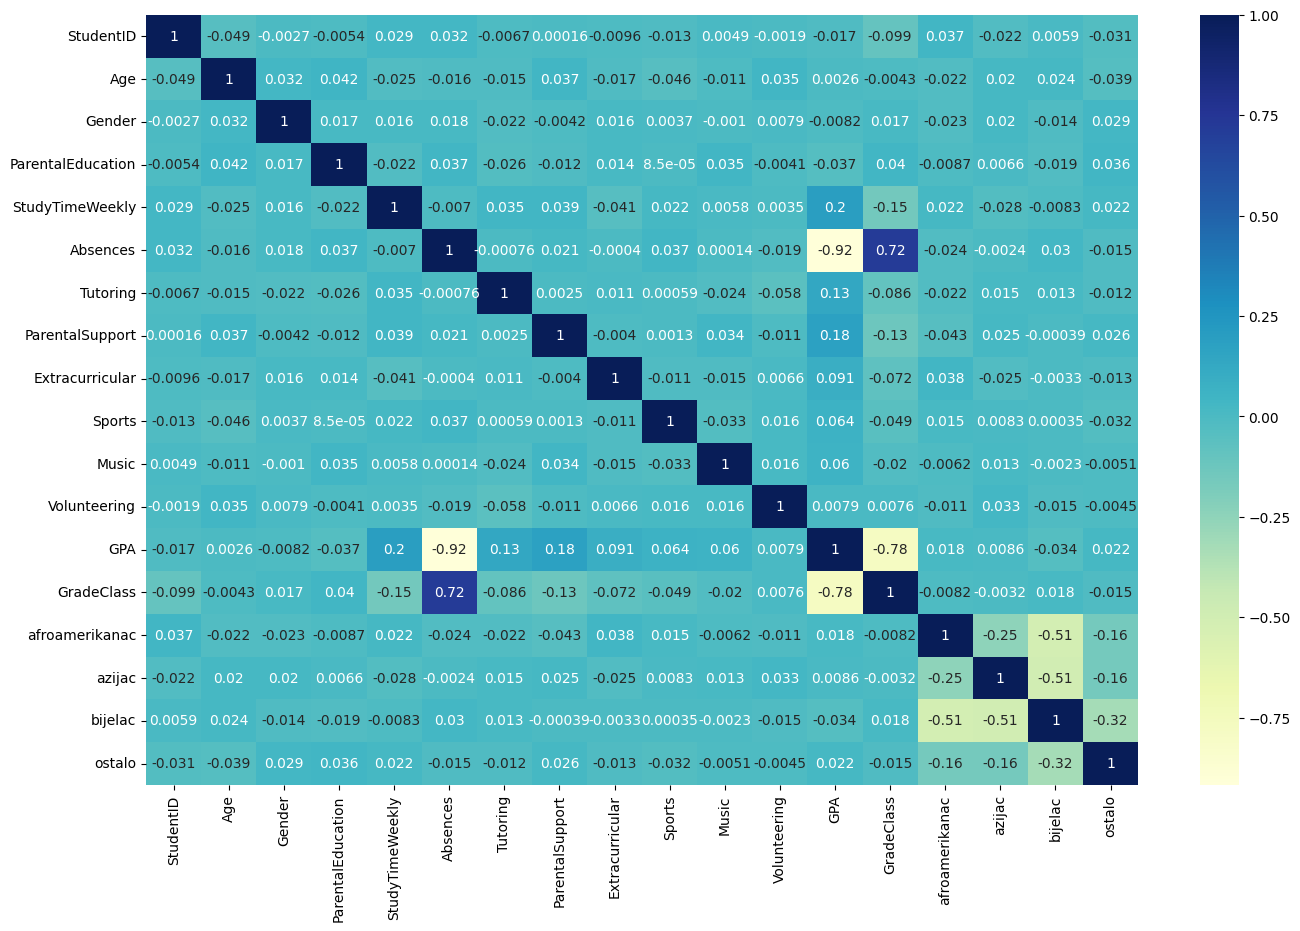

In [ ]:
#Odredjivanje korelacije izmedju izlaznih (target) varijabli (labela) i ulaznih znacajki (features)
plt.figure(figsize=(16,10))
sns.heatmap(df_train.corr(), annot=True, cmap="YlGnBu")

# Komentar 1b:
*   Buduci da je izlazna labela GradeClass dobijena izracunavanjem iz izlazne labele GPA ona ne nosi nikakve nove informacije za potrebe treninga modela linearne regresije (redundanta je) pa ce se za potrebe linearne regresije izbaciti. Ova izlazna labela ce biti koristena za potrebe klasifikacije studenata.
*   Znacajka StudentID ne bi trebala imati nikakvu korelaciju sa target varijablama buduci da je ili slucajna ili je dobijena leksikografskim redanjem imena studenata pa ce biti izbacena.
Vidljivo je da najvecu korelacija sa GPA imaju redom znacajke:
*   Absences = - 0.92 ; negativna korelacija sto znaci da povecanje odsustvovanja studenata smanjuje GPA. Ova znacajka ima najvecu vaznost za treniranje modela.
*   StudyTimeWeekly = 0.2 ; pozitivna korelacija sto znaci da povecanje ucenja tokom sedmice raste i GPA
*   ParentalSupport = 0.18 ; podrska roditelja ima takodjer znacajnu pozitivnu korelaciju sa GPA
*   Extracurricular = 0.091 ; imaju znacajan pozitivan uticaj na GPA
*   Tutoring = 0.13 ; imaju određeni pozitivan uticaj na GPA
*   Sport = 0.064 ; sport takodjer ima određeni pozitivan uticaj na GPA
*   Music = 0.06 ; takodjer bavljenje muzikom ima relativno veliki uticaj na GPA
*   ParentalEducation = -0.037 ; interesantno je primijetiti da edukacija roditelja ima negativnu korelaciju sa GPA
*   Nacionalna pripadnost (afroamerikanac, bijelac, azijac i ostalo) takodjer ima odredjenu, ali malu korelaciju sa GPA
*   Gender, Volunteering i Age imaju malu korelaciju sa GPA

# 2. Linearna i polinomijalna regresija
Modeliranje ovisnosti ocjena studenata i predikcije ocjena na osnovu znacajki studenata koristenjem metoda linearne i polinomijalne regresije. Klasa LinearRegression koristi neiterativnu (engl. closed-from solution) metodu najmanjih kvadrata za fitovanje modela. Model dobijen linearnom regresijom je u formi y = X * theta + b, gdje je X matrica znacajki, theta je vektor regresijskih koeficijenata, a b je bias (intercept). Model dobijen polinomijalnom regresijom je y = h(X, theta, stepen), gdje je h(X, theta, stepen) polinom stepena stepen po znacajkama.

*   Priprema podataka: izbacivanje kolona StudentID i GradeClass, pretvaranje DataFrame u vektore i matrice, skaliranje podataka koristeci minmax scaler.
*   Fitovanje modela koristeci klasu LinearRegression. Izborom varijable stepen se vrsi: linearna regresija (stepen = 1) ili polinomijalna regresija (stepen > 1)
*   Predikcija izlaza
*   Graficki prikaz rezultata, statisticka obrada rezultata, odredjivanje redoslijeda vaznosti znacajki i komentar rezultata
*   Izracunavanje klasa GradeClass na osnovu regresijskog modela i koristenjem formule za odredjivanje klasa koja je navedena u postavci zadatka
*   Komentar 2 o rezultatima regresije







In [ ]:
#DataFrame za regresiju sa izbacenim kolonama GradeClass i StudentID
data_reg = data.drop(columns=["GradeClass", "StudentID"])
print(data_reg.head(10))

   Age  Gender  ParentalEducation  StudyTimeWeekly  Absences  Tutoring  \
0   17       1                  2        19.833723         7         1   
1   18       0                  1        15.408756         0         0   
2   15       0                  3         4.210570        26         0   
3   17       1                  3        10.028829        14         0   
4   17       1                  2         4.672495        17         1   
5   18       0                  1         8.191219         0         0   
6   15       0                  1        15.601680        10         0   
7   15       1                  4        15.424496        22         1   
8   17       0                  0         4.562008         1         0   
9   16       1                  1        18.444466         0         0   

   ParentalSupport  Extracurricular  Sports  Music  Volunteering       GPA  \
0                2                0       0      1             0  2.929196   
1                1           

In [ ]:
#Trening i Test DataFrame  za regresiju sa izbacenim kolonama GradeClass i StudentID
df_train_reg = df_train.drop(columns=["GradeClass", "StudentID"])
print(df_train_reg.shape)
print(df_train_reg.head(10))
df_test_reg = df_test.drop(columns=["GradeClass", "StudentID"])
print(df_test_reg.head(10))

(1913, 16)
   Age  Gender  ParentalEducation  StudyTimeWeekly  Absences  Tutoring  \
0   18       1                  1         5.682083        11         1   
1   17       0                  3        11.666658        28         0   
2   18       0                  2         5.120423        13         0   
3   18       0                  2         4.919995         7         1   
4   18       1                  3         7.859015        19         0   
5   16       1                  2         3.425468        12         1   
6   15       0                  1         5.725181         1         0   
7   18       1                  3        15.958864        16         0   
8   15       1                  1         8.636102         6         1   
9   18       0                  1         8.210456         1         0   

   ParentalSupport  Extracurricular  Sports  Music  Volunteering       GPA  \
0                4                1       0      0             0  2.310235   
1                1

In [ ]:
#Definiranje funkcije za pretvaranje dataseta u matricu
def df_to_matrix(df):
    return df.iloc[:,:].values

In [ ]:
#Pretvaranje TRAIN izlaza u niz
y_train_reg = np.array(df_train_reg.pop("GPA"))    #Vrati kolonu GPA (izlaz) i pretvori u niz
y_train_reg.shape

(1913,)

In [ ]:
#Pretvaranje TRAIN ulaznog DataFrame u matricu
x_train_reg = df_to_matrix(df_train_reg)
print(df_train_reg.head(10))
x_train_reg.shape

   Age  Gender  ParentalEducation  StudyTimeWeekly  Absences  Tutoring  \
0   18       1                  1         5.682083        11         1   
1   17       0                  3        11.666658        28         0   
2   18       0                  2         5.120423        13         0   
3   18       0                  2         4.919995         7         1   
4   18       1                  3         7.859015        19         0   
5   16       1                  2         3.425468        12         1   
6   15       0                  1         5.725181         1         0   
7   18       1                  3        15.958864        16         0   
8   15       1                  1         8.636102         6         1   
9   18       0                  1         8.210456         1         0   

   ParentalSupport  Extracurricular  Sports  Music  Volunteering  \
0                4                1       0      0             0   
1                1                0       0      

(1913, 15)

In [ ]:
#Pretvaranje TEST izlaza u niz
y_test_reg = np.array(df_test_reg.pop("GPA"))
print(np.shape(y_test_reg))
#print(df_test_reg.head(10))
#print(y_test_reg.shape)
#Pretvaranje ulaznog TEST DataFrame u matricu
x_test_reg = df_to_matrix(df_test_reg)
print(x_test_reg.shape)

(479,)
(479, 15)


In [ ]:
#POLINOMIJALNA REGRESIJA (STEPEN >1) ILI LINEARNA REGRESIJA (STEPEN = 1) regresija zadatog stepena
from sklearn.preprocessing import PolynomialFeatures
stepen = 2
poly = PolynomialFeatures(degree = stepen, include_bias = False)   #kreiranje instance klase
x_train_reg_poly = poly.fit_transform(x_train_reg)                 #transformira train podatke u formu za trening
x_test_reg_poly = poly.fit_transform(x_test_reg)                   #transformira test podatke u formu za test

In [ ]:
#SKALIRANJE PODATAKA PRIJE FITOVANJA KORISTECI MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
min_max_scaler = MinMaxScaler()                                   #Kreiranje instance klase
min_max_scaler.fit(x_train_reg_poly)                              #Izracunavanje min i max za potrebe skaliranja
x_train_reg_scal = min_max_scaler.transform(x_train_reg_poly)     #Skaliranje
x_test_reg_scal = min_max_scaler.transform(x_test_reg_poly)

In [ ]:
#SKALIRANJE PODATAKA PRIJE FITOVANJA KORISTECI StandardScaler
#from sklearn.preprocessing import StandardScaler
#std_scaler = StandardScaler()                                 #Kreiranje instance klasde
#std_scaler.fit(x_train_reg)                                   #Izracunavanje min i max za potrebe skaliranja
#x_train_reg_std = std_scaler.transform(x_train_reg)           #Skaliranje
#x_test_reg_std = std_scaler.transform(x_test_reg)
#print(np.mean(x_train_reg_std))
#np.std(x_train_reg_std)

In [ ]:
#TRENIRANJE modela koristeci LinearRegression class (U osnovi je neiterativni metod najmanjih kvadrata)
from sklearn.linear_model import LinearRegression
model_reg = LinearRegression()
model_reg.fit(x_train_reg_scal, y_train_reg)
model_reg.score(x_train_reg_scal, y_train_reg)
print(f"Znacajke regresijskog polinoma: {df_train_reg.columns}")
print(f"Koeficijenti regresijskog polinoma: {model_reg.coef_}")
print(f"Bias regresijskog polinoma: {model_reg.intercept_}")


Znacajke regresijskog polinoma: Index(['Age', 'Gender', 'ParentalEducation', 'StudyTimeWeekly', 'Absences',
       'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music',
       'Volunteering', 'afroamerikanac', 'azijac', 'bijelac', 'ostalo'],
      dtype='object')
Koeficijenti regresijskog polinoma: [ 8.68023432e-01  3.20394637e-02  3.07940706e-01  5.79180408e-01
 -2.48667786e+00  1.43331315e-01  6.46671914e-01 -7.40007634e-02
  9.64851459e-03 -8.26109729e-03 -2.35054596e-02 -9.51270542e-03
 -8.63433841e-02  2.40781405e-02  7.17779491e-02 -8.85573460e-01
 -4.56861232e-02 -4.64339604e-01 -7.27976565e-02  2.52879280e-01
 -7.64404771e-02 -1.79034603e-01  4.04897145e-01  1.51177376e-01
  1.41705330e-01  6.42549340e-02  6.91566523e-02  2.34527662e-01
 -3.14096500e-02 -1.27604092e-01  3.20394637e-02  7.21601459e-02
  2.44284033e-02 -1.51553825e-02 -7.19670885e-03 -7.17321578e-02
  2.20844509e-02 -3.63556531e-02 -4.35790142e-02 -2.59218204e-02
 -2.03348649e-03  1.76860149e-02  1

In [ ]:
#Predikcija izlaza modela na trening i test podacima
y_train_reg_pred = model_reg.predict(x_train_reg_scal)
y_test_reg_pred = model_reg.predict(x_test_reg_scal)         #izracunavaje izlaza ako su na ulazu testni podaci

In [ ]:
#Stampanje prvih 10 izlaza
y_test_all = np.array([y_test_reg_pred, y_test_reg ], np.float32)
y_all_transposed = y_test_all.transpose()
print(y_all_transposed[0:9,:])

[[1.7809349 1.834227 ]
 [3.2495947 3.4544625]
 [1.8734258 1.7271203]
 [2.0434556 2.1686416]
 [2.398347  2.3961391]
 [2.8330982 2.6292114]
 [3.1096356 2.9527216]
 [1.8959146 2.1471717]
 [1.5993727 1.5820932]]


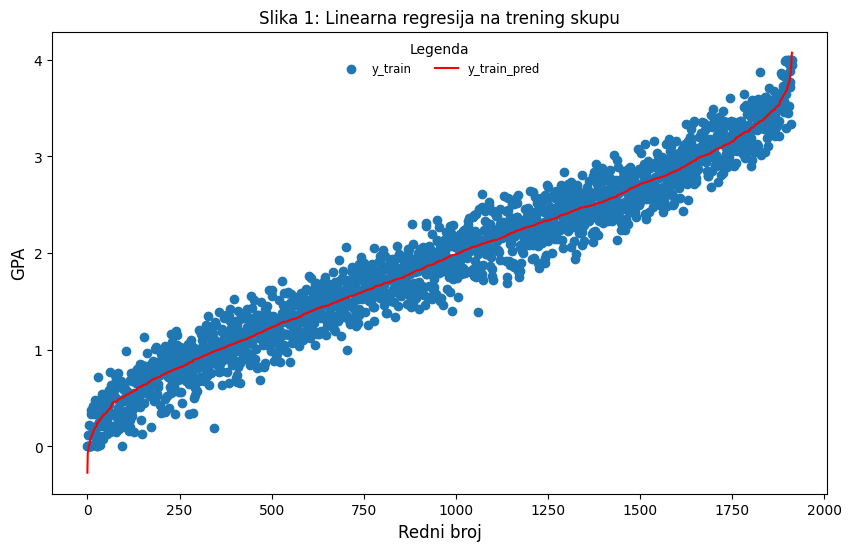

In [ ]:
#Priprema podataka za crtanje grafika i crtanje grafika
xosa = []
for i in range(len(y_train_reg)):
    xosa.append(i)
#Sortiranje y_train i y_train_pred
y_train_sorted = [y for _, y in sorted(zip(y_train_reg_pred, y_train_reg))]  #crtica znaci nije vazan parametar
y_train_pred_sorted = [y for _, y in sorted(zip(y_train_reg_pred, y_train_reg_pred))]
#Crtanje grafika podataka trening izlaza i predikcije izlaza
plt.figure(figsize=(10,6))
plt.title("Slika 1: Linearna regresija na trening skupu")
plt.scatter(xosa, y_train_sorted,label='y_train')
plt.plot(xosa, y_train_pred_sorted,c='red',label='y_train_pred')
plt.xlabel('Redni broj', fontsize = 12)
plt.ylabel('GPA', fontsize = 12)
plt.legend(loc='upper center', frameon=False, ncol=2, fontsize='small', title='Legenda')
plt.show()


In [ ]:
########## Statisticki pokazatelji kvaliteta fitovanog modela ##############

In [ ]:
#Izracunavanje trening gresaka i gresaka testiranja
from sklearn.metrics import mean_absolute_error,mean_squared_error
errors_tr = mean_absolute_error(y_train_reg,y_train_reg_pred)
errors_ts = mean_absolute_error(y_test_reg,y_test_reg_pred)
print(f"Srednja apsolutna trening greska: {errors_tr}")
print(f"Srednja apsolutna test greska: {errors_ts}")
print(f"Srednja kvadratna trening greska: {mean_squared_error(y_train_reg,y_train_reg_pred)}")

print(f"Srednja kvadratna test greska: {mean_squared_error(y_test_reg,y_test_reg_pred)}")

Srednja apsolutna trening greska: 0.15457556738865938
Srednja apsolutna test greska: 0.15669777846575733
Srednja kvadratna trening greska: 0.036902748679458496
Srednja kvadratna test greska: 0.0386379341209503


In [ ]:
#Statisticki pokazatelji apsolutnih testnih gresaka
errors_ts = abs(y_test_reg - y_test_reg_pred)
stats.describe(errors_ts)

DescribeResult(nobs=np.int64(479), minmax=(np.float64(3.9400874326300794e-05), np.float64(0.6535985289855315)), mean=np.float64(0.15669777846575733), variance=np.float64(0.014113204236781552), skewness=np.float64(1.0218740410524851), kurtosis=np.float64(1.1327018106869131))

/tmp/ipython-input-3105365180.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_train_reg - y_train_reg_pred), bins = 20)


Text(0.5, 0, 'Greska')

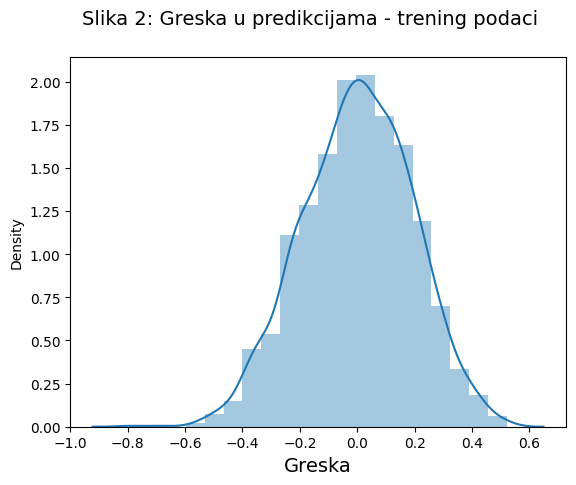

In [ ]:
#Crtanje distribucije greske u predikciji training podataka
fig = plt.figure()
sns.distplot((y_train_reg - y_train_reg_pred), bins = 20)
fig.suptitle('Slika 2: Greska u predikcijama - trening podaci', fontsize = 14)
plt.xlabel('Greska', fontsize = 14)

In [ ]:
red1,kol1 = x_train_reg_poly.shape
#print(kol1)
red2,kol2=x_train_reg.shape
#print(kol2)

In [ ]:
#Postupno iskljucivanje znacajki (osim najvaznije - Absences) sa ciljem odredjivanja njihove vaznosti
#Recursive feature elimination (RFE)
red1,kol1 = x_train_reg_poly.shape
red2,kol2 = x_train_reg.shape
if kol1 == kol2:
    from sklearn.feature_selection import RFE
    num_features = x_train_reg.shape[1]                      #Broj kolona DataFrame
    train_errors = []                                        #Inicijalizacija prazne lista trening gresaka
    test_errors = []                                         #Inicijalizacija prazne lista testing gresaka
    for i in range(num_features):
        lm1 = LinearRegression()
        rfe = RFE(lm1, n_features_to_select=num_features-i)
        rfe.fit(x_train_reg_scal,y_train_reg)

        discarded_features = np.array(df_train_reg.columns)[np.invert(rfe.support_)]
        discarded_features_ranks = np.array(rfe.ranking_)[np.invert(rfe.support_)]

        print(discarded_features)
        print(discarded_features_ranks)  #Koliko je bitna koja features

        lm2 = LinearRegression()
        lm2.fit(x_train_reg_scal[:,rfe.support_],y_train_reg)
        y_train_reg_pred = lm2.predict(x_train_reg_scal[:,rfe.support_])
        train_errors.append(mean_absolute_error(y_test_reg,y_test_reg_pred))

        y_test_reg_pred = lm2.predict(x_test_reg_scal[:,rfe.support_])
        test_errors.append(mean_absolute_error(y_test_reg,y_test_reg_pred))

    plt.plot(train_errors, label = "Trening greske")
    plt.plot(test_errors, label = "Test greske")
    plt.title("Slika 3: Ovisnost greski o znacajkama")
    plt.xlabel("Broj izbacenih znacajki")
    plt.ylabel("Apsolutna greska")
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
print(f"Koeficijenti modela su: {model_reg.coef_}")

Koeficijenti modela su: [ 8.68023432e-01  3.20394637e-02  3.07940706e-01  5.79180408e-01
 -2.48667786e+00  1.43331315e-01  6.46671914e-01 -7.40007634e-02
  9.64851459e-03 -8.26109729e-03 -2.35054596e-02 -9.51270542e-03
 -8.63433841e-02  2.40781405e-02  7.17779491e-02 -8.85573460e-01
 -4.56861232e-02 -4.64339604e-01 -7.27976565e-02  2.52879280e-01
 -7.64404771e-02 -1.79034603e-01  4.04897145e-01  1.51177376e-01
  1.41705330e-01  6.42549340e-02  6.91566523e-02  2.34527662e-01
 -3.14096500e-02 -1.27604092e-01  3.20394637e-02  7.21601459e-02
  2.44284033e-02 -1.51553825e-02 -7.19670885e-03 -7.17321578e-02
  2.20844509e-02 -3.63556531e-02 -4.35790142e-02 -2.59218204e-02
 -2.03348649e-03  1.76860149e-02  1.03514416e-02  6.03549367e-03
  2.10727311e-03  6.70214258e-03  9.70005025e-02  2.84292278e-02
 -9.87704688e-02 -4.12578273e-02  3.01215199e-02  5.13502751e-02
  5.01828533e-03  1.38079391e-01  5.29361407e-02  4.88095405e-02
  6.81156331e-02 -8.05971406e-02 -9.46829129e-03 -1.84403116e-02
 

In [ ]:
print(f"Bias(intercept) modela je: {model_reg.intercept_}")

Bias(intercept) modela je: 2.465956236608363


#Klasifikacija primjenom regresije

In [ ]:
from sklearn.metrics import accuracy_score
#Izracunavanje GradeClass na osnovu regresijskog modela procesa -train podacu
y_train_pom = np.array(df_train["GradeClass"])
y_train_reg_cal=[]
for i in range(len(y_train_reg_pred)):
  if y_train_reg_pred[i] >= 3.5:
    y_train_reg_cal.append(0)
  elif y_train_reg_pred[i] < 3.5 and y_train_reg_pred[i] >= 3:
    y_train_reg_cal.append(1)
  elif y_train_reg_pred[i] < 3 and y_train_reg_pred[i] >= 2.5 :
    y_train_reg_cal.append(2)
  elif y_train_reg_pred[i] < 2.5 and y_train_reg_pred[i] >= 2 :
    y_train_reg_cal.append(3)
  elif y_train_reg_pred[i] < 2:
    y_train_reg_cal.append(4)
y_train_reg_cal = np.array(y_train_reg_cal)
print(f"Tacnost predikcije GradeClass na trening podacima: {accuracy_score(y_train_pom, y_train_reg_cal)}")

Tacnost predikcije GradeClass na trening podacima: 0.7746994249869316


In [ ]:
#Izracunavanje GradeClass na osnovu regresijskog modela procesa - test podaci
y_test_pom = np.array(df_test["GradeClass"])
y_test_reg_cal=[]
for i in range(len(y_test_reg_pred)):
  if y_test_reg_pred[i] >= 3.5:
    y_test_reg_cal.append(0)
  elif y_test_reg_pred[i] < 3.5 and y_test_reg_pred[i] >= 3:
    y_test_reg_cal.append(1)
  elif y_test_reg_pred[i] < 3 and y_test_reg_pred[i] >= 2.5 :
    y_test_reg_cal.append(2)
  elif y_test_reg_pred[i] < 2.5 and y_test_reg_pred[i] >= 2 :
    y_test_reg_cal.append(3)
  elif y_test_reg_pred[i] < 2:
    y_test_reg_cal.append(4)
y_test_reg_cal = np.array(y_test_reg_cal)
print(f"Tacnost predikcije GradeClass na test podacima: {accuracy_score(y_test_pom, y_test_reg_cal)}")

Tacnost predikcije GradeClass na test podacima: 0.7724425887265136


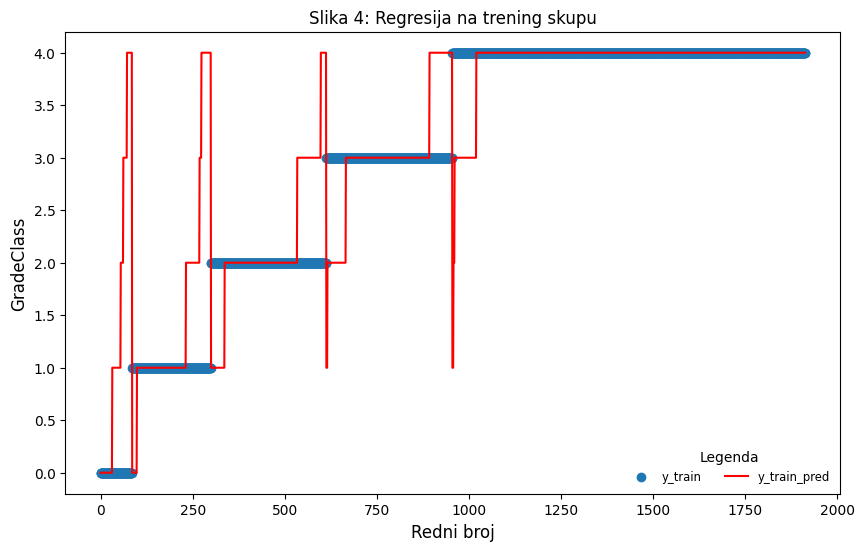

In [ ]:
#Priprema podataka za crtanje grafika i crtanje grafika
xosa = []
for i in range(len(y_train_pom)):
    xosa.append(i)
#Sortiranje y_train i y_train_pred
y_train_sorted = sorted(y_train_pom)
y_train_pred_sorted = [y for _, y in sorted(zip(y_train_pom, y_train_reg_cal))]
#Crtanje grafika podataka trening izlaza i predikcije izlaza
plt.figure(figsize=(10,6))
plt.title("Slika 4: Regresija na trening skupu")
plt.scatter(xosa, y_train_sorted,label='y_train')
plt.plot(xosa, y_train_pred_sorted,c='red',label='y_train_pred')
plt.xlabel('Redni broj', fontsize = 12)
plt.ylabel('GradeClass', fontsize = 12)
plt.legend(loc='lower right', frameon=False, ncol=2, fontsize='small', title='Legenda')
plt.show()


Matrica konfuzije: [[  8   9   1   1   2]
 [  1  37  12   4   1]
 [  0  14  51  10   3]
 [  1   3  10  40  18]
 [  0   3   0  16 234]]


Text(0.5, 155.72222222222217, 'y_pred')

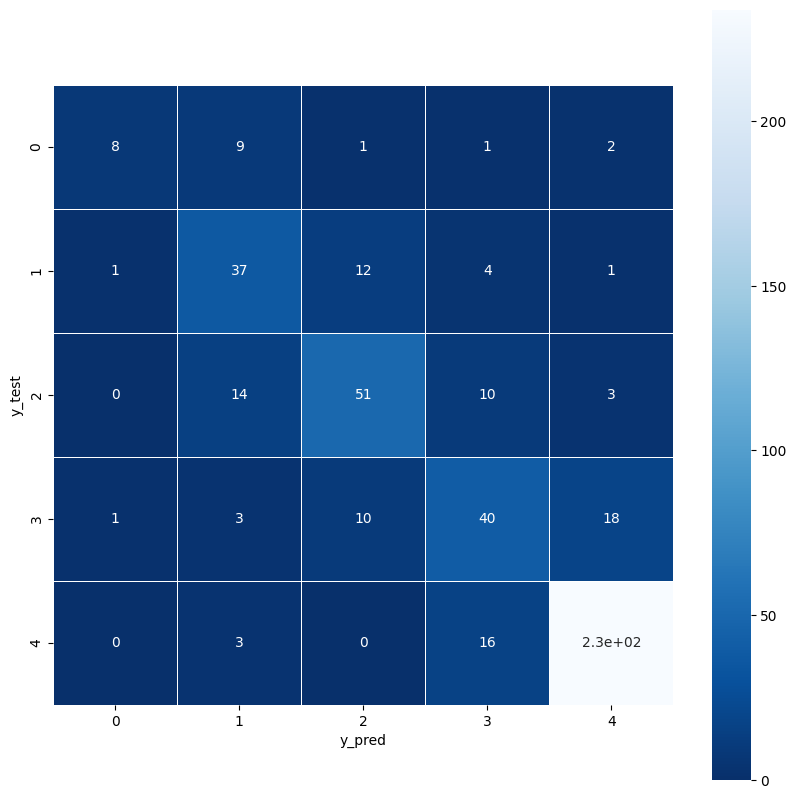

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_pom, y_test_reg_cal)
print(f"Matrica konfuzije: {cm}")
plt.figure(figsize=(10,10))
sns.heatmap(cm, annot=True, square=True, linewidth=0.5, cmap ="Blues_r")
plt.ylabel("y_test")
plt.xlabel("y_pred")

# Komentar 2:

Model dobijen primjenom metoda linearne regresije je u formi:


*   y = X * theta + b
pri cemu su koeficijenti theta uz regresijske varijable x kako slijedi:

*   'Age'                               -0.01478241                              
*   'Gender'                             0.01295703                           
*   'ParentalEducation'                  0.00976421
*   'StudyTimeWeekly'                    0.57185142                              
*   **'Absences'**                           **-2.88487174**
*   'Tutoring'                            0.2470292                              
*   'ParentalSupport'                     0.60872111
*   'Extracurricular'                     0.18505314                              
*   'Sports'                              0.19069914
*   'Music'                               0.13727231                             
*   'Volunteering'                       -0.01051042
*   'afroamerikanac'                     -0.00734415
*   'azijac'                              0.0063666
*   'bijelac'                            -0.01005911
*   'ostalo'                              0.01103666


Bias regresijskog polinoma je b =        2.5211483706140148

*   Primjenom linearne regresije dobijene su sljedece vrijednosti gresaka:
    *   Srednja apsolutna trening greska: 0.15905686944763786
    *   Srednja apsolutna test greska: 0.15535504175489762
    *   Srednja kvadratna trening greska: 0.03888984923446642
    *   Srednja kvadratna test greska: 0.037037411731997254

*   Primjenom polinomijalne regresije stepena 2 dobijene su sljedece vrijednosti gresaka:    
    *   Srednja apsolutna trening greska:  0.15457556738865938
    *   Srednja apsolutna test greska: 0.15669777846575733
    *   Srednja kvadratna trening greska: 0.036902748679458496
    *   Srednja kvadratna test greska: 0.0386379341209503

Vidljivo je da su srednje greske u slucaju primjene polinomijalne regresije u odnosu na linearnu vrlo bliske. Takodjer se vidi da i slucaju primjene linearne i polinomijalne regresije nije doslo do overfittinga buduci da su srednje test greske priblizno jednake srednjim trening greskama, što je prvenstveno posljedica dobrog (slucajnog) odabira trening i test skupova i da su trening i test podaci iz iste populacije.

*   Na osnovu Slika 1: vizuelno se moze zakljuciti da fitovani model dosta dobro (u srednjem) modelira DataSet
*   Na osnovu Slika 2: moze se zakljuciti da su greske u predikciji slucajno distribuirane sa srednjom vrijednoscu nula, priblizno prema Normalnoj raspodjeli, što je i pretpostavka za primjenu metoda najmanjih kvadrata
*   Na osnovu Slika 3 kao i vrijednosti koeficijenata regresijskog polinoma moze se zakljuciti da najvecu vaznost imaju redom znacajke: **'Absences'**, 'ParentalSupport', 'StudyTimeWeekly', 'Tutoring', 'Sports', 'Extracurricular' i 'Music'. Znacajke: 'Age', 'Gender', 'Ethnicity', 'Volunteering' i 'ParentalEducation' imaju vrlo malu korelaciju sa izlaznom labelom GPA pa su im pridruzeni koeficijenti u modelu veoma mali. Daleko najveci uticaj na target (ciljnu) varijablu GPA ima znacajka '**Absences'**
*   Na osnovu matrice konfuzije je zakljuceno da bolju predikciju kategoricke ocjene studenata daje polinomijalna regresija u odnosu na linearnu. Nedovoljno dobri rezultati klasifikacije su posljedica nedovoljne **separabilnosti** klasa s obzirom na nacin odredjivanja pripadnosti uzorka  kao i prilicno velikog suma u podacima. Naime, vrlo mala razlika u GPA ocjeni koja je na granici klasa dovodi do promjene klase uzorka.
Tacnost predikcije klasa na trening podacima je 0.7746994249869316 (77.5%), dok je tacnost predikcije na test podacima je 0.7724425887265136 (77.2%) sto je pokazatelj da nije doslo do overfittinga (preprilagodjavanja).


# 3. Multinomijalna logisticka regresija (klasifikacija)

Multinomijalna logisticka regresija je obavljena koristenjem klase LogisticRegression. Koristeni metod optimizacije funkcije gubitaka je 'lbfgs', metod regularizacije 'l2', balansirana tezina klasa.


Sadrzaj:

*   Izbacivanje kolona StudentID i GPA
*   Pretvaranje DataFrame u vektore i matrice
*   Provjera da li su trening i test podaci dobro balansirani (histogram klasa)
*   Izbor stepena regresijskog modela (stepena 1 ili veceg stepena)
*   Skaliranje podataka koristeci StandardScaler
*   Fitovanje modela koristeci klasu LogisticRegression
*   Predikcija izlaza
*   Graficki prikaz rezultata i statisticka obrada rezultata
*   Komentar 3 o rezultatima klasifikacije


In [ ]:
#DataFrame za multinomijalnu logisticku regresiju sa izbacenim kolonama GPA i StudentID
data_klas = data.drop(columns=["GPA", "StudentID"])
#print(data_klas.head(10))
#data_reg.head(10)

In [ ]:
#Trening i Test DataFrame  za klasifikaciju sa izbacenom kolonama GPA i StudentID
df_train_klas = df_train.drop(columns=["GPA", "StudentID"])
print(df_train_klas.shape)
#print(df_train_klas.head(10))
df_test_klas = df_test.drop(columns=["GPA", "StudentID"])
#print(df_test_klas.head(10))
print(df_test_klas.shape)

(1913, 16)
(479, 16)


In [ ]:
#Prevodjenje DataFrame u vektor i matricu
y_train_klas = np.array(df_train_klas.pop('GradeClass'))
x_train_klas = df_to_matrix(df_train_klas)
y_test_klas = np.array(df_test_klas.pop('GradeClass'))
x_test_klas = df_to_matrix(df_test_klas)
print(x_train_klas.shape)
print(y_train_klas.shape)

(1913, 15)
(1913,)


Text(0.5, 1.0, 'Histogram klasa u test setu')

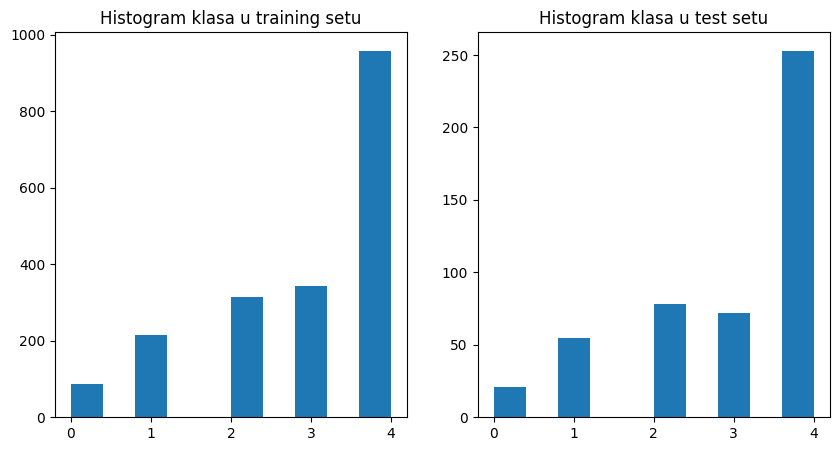

In [ ]:
#Povjera da li je DataSet dobro balansiran tj. da su trening i test DataSet slicne distribucije
#Dobro je da test i training test budu slicne distribucije
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.hist(y_train_klas)
plt.title("Histogram klasa u training setu")
plt.subplot(1,2,2)
plt.hist(y_test_klas)
plt.title("Histogram klasa u test setu")

In [ ]:
#Izbor stepena modela klasifikacija zadatog stepena
from sklearn.preprocessing import PolynomialFeatures
stepen = 1
poly = PolynomialFeatures(degree = stepen, include_bias =False)   #kreiranje instance klase
x_train_klas_poly = poly.fit_transform(x_train_klas)    #tansformira train podatke u formu za trening
x_test_klas_poly = poly.fit_transform(x_test_klas)      #transformira test podatke u formu za test

In [ ]:
#Skaliranje podataka koristeci StandardScaler
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()                                   #Kreiranje instance klase
std_scaler.fit(x_train_klas_poly)                                    #Izracunavanje min i max za potrebe skaliranja
x_train_klas_std = std_scaler.transform(x_train_klas_poly)           #Skaliranje
x_test_klas_std = std_scaler.transform(x_test_klas_poly)
#print(np.mean(x_train_klas_std))
#np.std(x_train_klas_std)

In [ ]:
print(x_train_klas_std[:10])
print(np.mean(x_train_klas_std))

[[ 1.35137827  0.99530636 -0.74240579 -0.72438799 -0.41715944  1.51413307
   1.67767225  1.2786658  -0.66126032 -0.49214611 -0.43551879 -0.50114323
  -0.49378451  0.97674701 -0.31731758]
 [ 0.46146893 -1.00471577  1.25369018  0.335001    1.60496638 -0.66044393
  -0.98204075 -0.78206518 -0.66126032 -0.49214611 -0.43551879 -0.50114323
   2.02517489 -1.02380656 -0.31731758]
 [ 1.35137827 -1.00471577  0.25564219 -0.82381291 -0.17926228 -0.66044393
   0.79110125 -0.78206518 -0.66126032 -0.49214611  2.29611218  1.9954375
  -0.49378451 -1.02380656 -0.31731758]
 [ 1.35137827 -1.00471577  0.25564219 -0.85929278 -0.89295375  1.51413307
  -0.09546975  1.2786658   1.51226373 -0.49214611 -0.43551879 -0.50114323
   2.02517489 -1.02380656 -0.31731758]
 [ 1.35137827  0.99530636  1.25369018 -0.33902762  0.53442918 -0.66044393
   1.67767225 -0.78206518  1.51226373  2.03191691 -0.43551879 -0.50114323
  -0.49378451  0.97674701 -0.31731758]
 [-0.42844041  0.99530636  0.25564219 -1.12385375 -0.29821086  1.5

In [ ]:
#Fitovanje modela koristenjem LogisticRegression klase
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

model_mlc = LogisticRegression(solver = 'lbfgs', random_state=0,class_weight = 'balanced',
                          max_iter=1000, verbose=0, penalty ='l2',tol = 1e-8,C = 1).fit(x_train_klas_std, y_train_klas)
#print(mclf.score(x_train_klas, y_train_klas, sample_weight=None))
y_train_klas_pred = model_mlc.predict(x_train_klas_std)
print(f"Tacnost predikcije na trening podacima: {accuracy_score(y_train_klas, y_train_klas_pred)}")
print(f"Nazivi klasa: {model_mlc.classes_}")
print(f"Koeficijenti modela: {model_mlc.coef_}")
print(f"Biasi modela: {model_mlc.intercept_}")

Tacnost predikcije na trening podacima: 0.6382645060115003
Nazivi klasa: [0. 1. 2. 3. 4.]
Koeficijenti modela: [[-3.96184284e-02 -1.23567373e-01  5.08326902e-03  4.05873431e-01
  -9.68127024e-01  2.10810226e-01  5.24215517e-01  2.52256965e-01
   1.24307977e-01 -1.16921561e-02 -5.18624113e-04 -3.88377669e-02
   1.11269833e-01 -4.10631986e-02 -2.80642649e-02]
 [ 1.81766011e-02  6.15176960e-03 -4.98144686e-02  2.06818600e-01
  -1.10447532e+00  1.45016973e-01  2.37866993e-01  5.64390859e-02
   8.49652277e-02  7.63368413e-02 -1.63490730e-02 -4.34586263e-03
  -7.21182616e-02  5.83233256e-02  4.22253403e-03]
 [ 6.89425641e-02 -2.62937736e-02 -3.20955268e-02 -4.50743440e-03
  -5.03403794e-01 -5.14023438e-02 -1.42470170e-01  2.44464355e-02
  -4.92618864e-03 -4.26895578e-02 -3.56845169e-02 -1.58767044e-02
  -6.30225953e-02  6.15189321e-02  2.17740325e-03]
 [ 5.25131143e-03  3.10425004e-02  2.73667319e-02 -1.41484918e-01
   4.07625990e-01 -1.34794500e-01 -1.31528192e-01 -9.37366575e-02
  -5.83015

In [ ]:
#Tacnost predikcije na testnim podacima
y_test_klas_pred = model_mlc.predict(x_test_klas_std)
print(f"Tacnost predikcije na testnom podacima:{accuracy_score(y_test_klas, y_test_klas_pred)}")

Tacnost predikcije na testnom podacima:0.6409185803757829


In [ ]:
#Stampanje prvih 10 izlaza
y_test_klas_all = np.array([y_test_klas_pred, y_test_klas], np.float32)
y_klas_all_transposed = y_test_klas_all.transpose()
print(y_klas_all_transposed[0:10,:])

[[4. 4.]
 [1. 1.]
 [3. 4.]
 [3. 3.]
 [2. 3.]
 [1. 2.]
 [0. 2.]
 [2. 3.]
 [4. 4.]
 [2. 1.]]


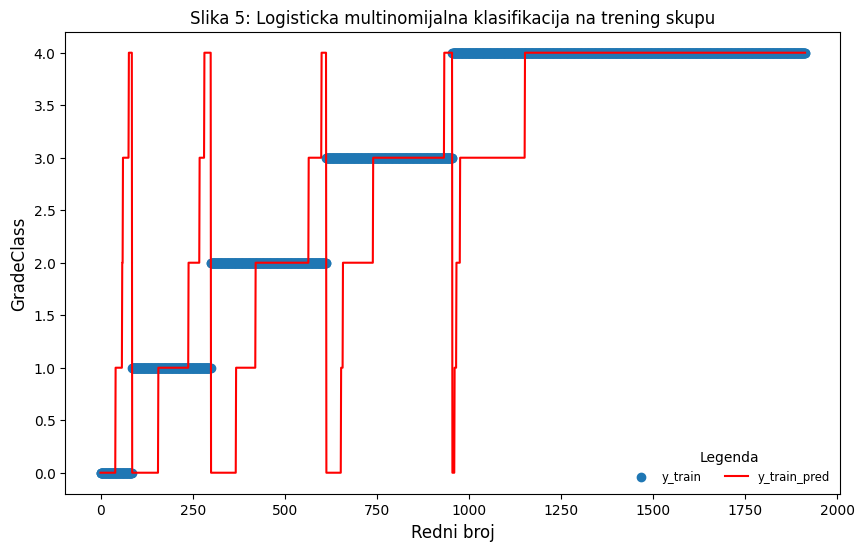

In [ ]:
#Priprema podataka za crtanje grafika i crtanje grafika
xosa = []
for i in range(len(y_train_klas)):
    xosa.append(i)
#Sortiranje y_train i y_train_pred
y_train_sorted = [y for _, y in sorted(zip(y_train_klas, y_train_klas))]
y_train_pred_sorted = [y for _, y in sorted(zip(y_train_klas, y_train_klas_pred))]
#Crtanje grafika podataka trening izlaza i predikcije izlaza
plt.figure(figsize=(10,6))
plt.title("Slika 5: Logisticka multinomijalna klasifikacija na trening skupu")
plt.scatter(xosa, y_train_sorted,label='y_train')
plt.plot(xosa, y_train_pred_sorted,c='red',label='y_train_pred')
plt.xlabel('Redni broj', fontsize = 12)
plt.ylabel('GradeClass', fontsize = 12)
plt.legend(loc='lower right', frameon=False, ncol=2, fontsize='small', title='Legenda')
plt.show()


Matrica konfuzije: [[ 10   7   1   1   2]
 [ 21  23   8   2   1]
 [ 24  16  27   8   3]
 [  5   3  16  40   8]
 [  4   0   5  37 207]]


Text(0.5, 155.72222222222217, 'y_pred')

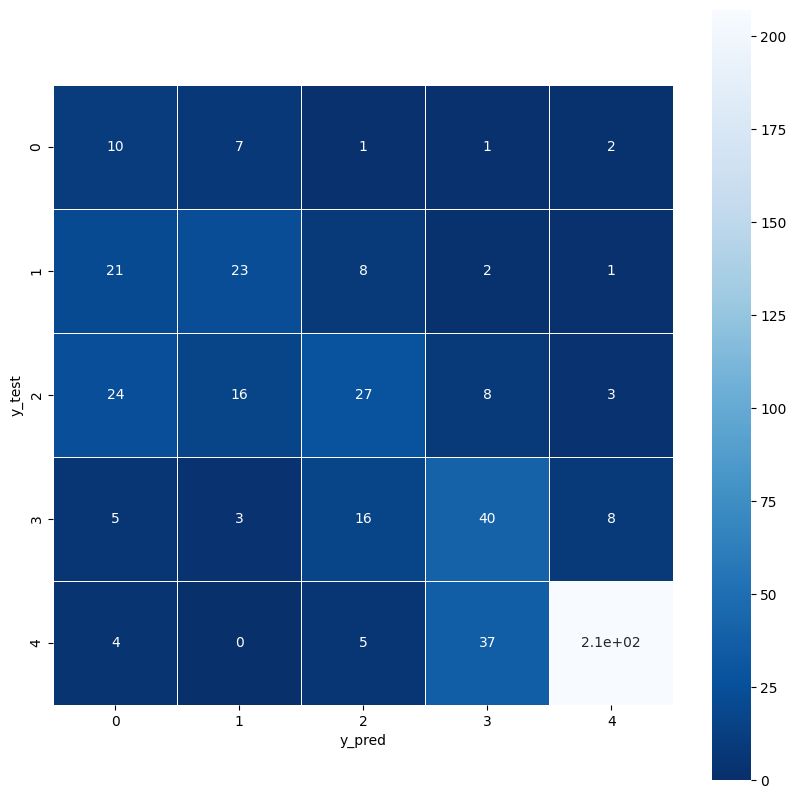

In [ ]:
#Izracunavanje matrice konfuzije na test podacima (koliko puta je klasifiktor grijesio po klasama)
from sklearn.metrics import confusion_matrix
y_test_pred = model_mlc.predict(x_test_klas_std)
cm = confusion_matrix(y_test_klas, y_test_pred)
print(f"Matrica konfuzije: {cm}")
plt.figure(figsize=(10,10))
sns.heatmap(cm, annot=True, square=True, linewidth=0.5, cmap ="Blues_r")
plt.ylabel("y_test")
plt.xlabel("y_pred")


# Komentar 3
Na osnovu histograma klasa trening i test podataka je vidljivo da su podaci dobro balansirani jer je distribucija klasa slicna za trening i test podatke.



*   Tacnost predikcije trening podataka je 0.6382645060115003 dok je tacnost predikcije test podataka 0.64091858037578291. Tacnost predikcije je dosta mala ali je takodjer vidljivo da nije doslo do overfittinga.
*   Na slici 5 su prikazane sortirane target varijable trening skupa i sortirane predikovane vrijednosti target varijabli na kojoj se vidi da je tacnost klasifikacije iznad slucajne (iznad 50%) ali je dosta mala
*   Usporedbom matrice konfuzije sa matricom konfuzije klasifikacije dobijene izracunavanjem iz modela regresije i usporedbom tacnosti predikcije vidljivo je da je tacnost klasifikacije koristenjem metoda multinomijalne klasifikacije dosta manja




# 4. Neuronska mreža - primjena u klasifikaciji

Koristena je neuronska mreza (MLPClassifier) sa jednim ulaznim i jednim izlaznim slojem i tri skrivena sloja sa po 100, 50 i 50 neurona redom. Koristeni metod minimizacije funkcije gubitaka je 'lbfgs' sa adaptivnim koeficijentom brzine ucenja i koeficijentom regularizacije alpha = 30. Aktivacijske funkcije su tipa 'relu'.

Sadrzaj

*   Postavljanje najviseg stepena regresorskih varijabli
*   Skaliranje podataka koristeci StandardScaler
*   Treniranje modela koristeci MLPClassifier
*   Statisticka analiza izvrsenog treninga
*   Izracunavanje matrice konfuzije i graficki prikaz kvaliteta klasifikacije
*   Komentar 4 o rezultatima treninga





In [ ]:
#Postavljanje najviseg stepena regresorskih varijabli
from sklearn.preprocessing import PolynomialFeatures
stepen = 1
poly = PolynomialFeatures(degree = stepen, include_bias =False)   #kreiranje instance klase
x_train_klas_poly = poly.fit_transform(x_train_klas)              #tansformira train podatke u formu za trening
x_test_klas_poly = poly.fit_transform(x_test_klas)                #transformira test podatke u formu za test

In [ ]:
#Skaliranje podataka koristeci StandardScaler
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()                                        #Kreiranje instance klase
std_scaler.fit(x_train_klas_poly)                                    #Izracunavanje min i max za potrebe skaliranja
x_train_klas_std = std_scaler.transform(x_train_klas_poly)           #Skaliranje
x_test_klas_std = std_scaler.transform(x_test_klas_poly)
#print(np.mean(x_train_klas_std))
#np.std(x_train_klas_std)

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
#Parametri neuronske mreze
batch_size = 10
alpha = 30                                               #parametar regularizacije
learning_rate_init = 1e-3                                #brzina ucenja
hidden_layer_sizes = [100,50,50]                         #broj neurona u skrivenom sloju mreze 200
solver ='lbfgs'                                          #algoritam optimizacije
#solver = 'adam'
max_iter=500                                             #maksimalan broj iteracija
#Trening neuronske mreze
model_mlpc=MLPClassifier(verbose = True, hidden_layer_sizes = hidden_layer_sizes, early_stopping = True,
                         learning_rate ='adaptive',shuffle = True,validation_fraction = 0.5,
                         solver = solver, alpha = alpha, batch_size = batch_size,
                         learning_rate_init=learning_rate_init, max_iter=max_iter, activation = 'relu')
#clf=MLPClassifier(verbose = False, hidden_layer_sizes = [100,50,50, 50],learning_rate ='adaptive',shuffle = True,
                  #solver ="sgd", alpha=6e-2, batch_size = 10, learning_rate_init=1e-3, max_iter=1000,validation_fraction = 0.5)
model_mlpc.fit(x_train_klas_std, y_train_klas)
y_train_nn_pred = model_mlpc.predict(x_train_klas_std)
y_test_nn_pred = model_mlpc.predict(x_test_klas_std)
print(f"Nazivi klasa: {model_mlpc.classes_}")
print(f"Broj slojeva nn mreze: {model_mlpc.n_layers_}")
print(f"Broj neurona u skrivenom sloju nn mreze: {hidden_layer_sizes}")
print(f"Broj neurona u izlaznom sloju nn mreze: {model_mlpc.n_outputs_}")
print(f"Tacnost predikcije na trening podacima: {accuracy_score(y_train_klas, y_train_nn_pred)}")
print(f"Tacnost predikcije na testnim podacima: {accuracy_score(y_test_klas, y_test_nn_pred)}")
print(f"Dimenzije matrice koeficijenata u ulaznom sloju: {np.array(model_mlpc.coefs_[0]).shape}")     #dimenzija matrice koeficijentata u prvom sloju

Nazivi klasa: [0. 1. 2. 3. 4.]
Broj slojeva nn mreze: 5
Broj neurona u skrivenom sloju nn mreze: [100, 50, 50]
Broj neurona u izlaznom sloju nn mreze: 5
Tacnost predikcije na trening podacima: 0.7820177731312076
Tacnost predikcije na testnim podacima: 0.7682672233820459
Dimenzije matrice koeficijenata u ulaznom sloju: (15, 100)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [ ]:
#Crtanje grafika funkcije gubitaka tokom treninga
import matplotlib.pyplot as plt
if solver == 'adam':
  xosa=[]
  for i in range(len(model_mlpc.loss_curve_)):
      xosa.append(i)
  plt.figure(figsize=(10,6))
  plt.title('Slika 5: Training loss')
  plt.xlabel('Iteration')
  plt.plot(xosa, model_mlpc.loss_curve_,c='red',label='y_train_pred')
  plt.show()

Matrica konfuzije: [[  3  14   1   1   2]
 [  0  36  15   1   3]
 [  0   7  58  10   3]
 [  0   4  12  38  18]
 [  0   3   0  17 233]]


Text(0.5, 155.72222222222217, 'y_pred')

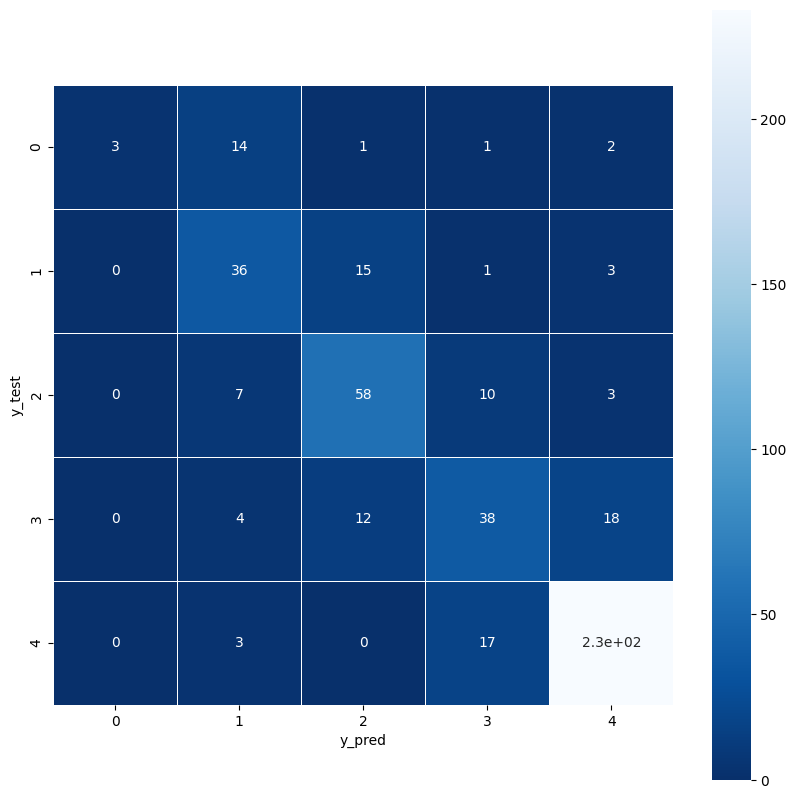

In [ ]:
#Izracunavanje matrice konfuzije na test podacima (koliko puta je klasifiktor grijesio po klasama)
from sklearn.metrics import confusion_matrix
y_test_pred = model_mlpc.predict(x_test_klas_std)
cm = confusion_matrix(y_test_klas, y_test_pred)
print(f"Matrica konfuzije: {cm}")
plt.figure(figsize=(10,10))
sns.heatmap(cm, annot=True, square=True, linewidth=0.5, cmap ="Blues_r")
plt.ylabel("y_test")
plt.xlabel("y_pred")

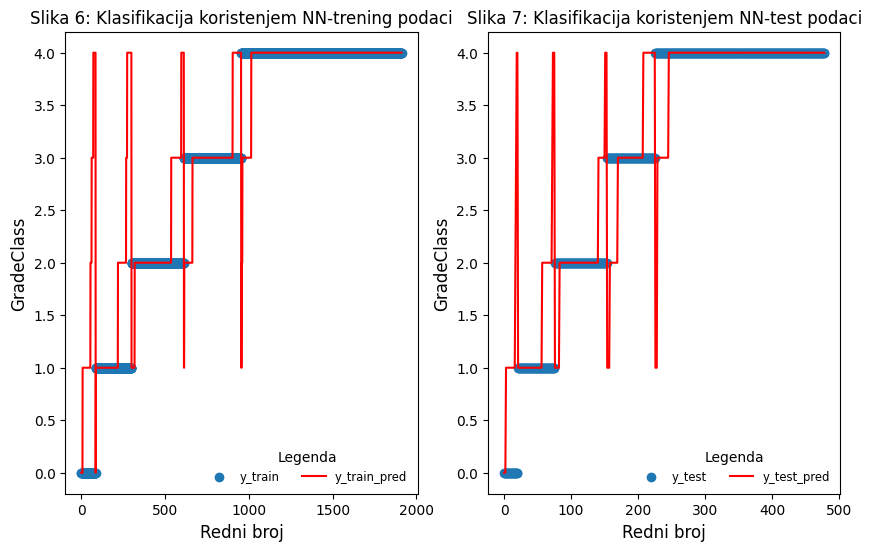

In [ ]:
#Priprema podataka za crtanje grafika i crtanje grafika na bazi trening podataka
xosa1 = []
for i in range(len(y_train_klas)):
    xosa1.append(i)
#Sortiranje y_train i y_train_pred
y_train_sorted = sorted(y_train_klas)
y_train_pred_sorted = [y for _, y in sorted(zip(y_train_klas, y_train_nn_pred))]
#Crtanje grafika podataka trening izlaza i predikcije izlaza
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.title("Slika 6: Klasifikacija koristenjem NN-trening podaci")
plt.scatter(xosa1, y_train_sorted,label='y_train')
plt.plot(xosa1, y_train_pred_sorted,c='red',label='y_train_pred')
plt.xlabel('Redni broj', fontsize = 12)
plt.ylabel('GradeClass', fontsize = 12)
plt.legend(loc='lower right', frameon=False, ncol=2, fontsize='small', title='Legenda')
#Priprema podataka za crtanje grafika i crtanje grafika na bazi testing podataka
xosa2 = []
for i in range(len(y_test_klas)):
    xosa2.append(i)
#Sortiranje y_train i y_train_pred
y_test_sorted = sorted(y_test_klas)
y_test_pred_sorted = [y for _, y in sorted(zip(y_test_klas, y_test_nn_pred))]
#Crtanje grafika podataka trening izlaza i predikcije izlaza
plt.subplot(1,2,2)
plt.title("Slika 7: Klasifikacija koristenjem NN-test podaci")
plt.scatter(xosa2, y_test_sorted,label='y_test')
plt.plot(xosa2, y_test_pred_sorted,c='red',label='y_test_pred')
plt.xlabel('Redni broj', fontsize = 12)
plt.ylabel('GradeClass', fontsize = 12)
plt.legend(loc='lower right', frameon=False, ncol=2, fontsize='small', title='Legenda')
plt.show()

# Komentar 4


*   Tacnost predikcije trening podataka je 0.77992681651855728 dok je tacnost predikcije test podataka 0.7745302713987474 sto je pokazatelj da nije doslo do overfittinga
*   Na slikama 6 i 7 su prikazane sortirane target varijable trening i test skupa i sortirane predikovane vrijednosti target varijabli na kojoj se vidi da je tacnost klasifikacije uporediva sa rezultatima dobijenim primjenom polinomijalne regresije.


# 5. ZAKLJUCAK-Komparacija metoda klasifikacije

Tacnost predikcije klasa primjenom:

Metoda polinomijalne regresije (2. stepena) sa izracunom klasa
*   na trening podacima 0.7746994249869316
*   na test podacima 0.7724425887265136

Metoda multimonijalne regresije (klasifikacije)
*   na trening podacima 0.6382645060115003
*   na test podacima 0.6409185803757829

Neuronskih mreza
*   na trening podacima 0.7799268165185572
*   na test podacima 0.7745302713987474

Najbolje rezultate (tacnost predikcije u procentima) su postignute metodom polinomijalne regresije (2. stepena) sa izracunom klasa i primjenom neuronskih mreza **(tacnost predikcije test podataka je oko 77.5%).** **Interesantno je primijetiti da se objema metodama dobila priblizno ista tacnost na test podacima?!**. Nedovoljno dobri rezultati klasifikacije su posljedica nedovoljne separabilnosti klasa s obzirom na nacin odredjivanja klase uzorka kao i prilicno velikog suma u podacima. Naime, vrlo mala razlika u GPA ocjeni koja je na granici klasa dovodi do promjene klase uzorka. Tacnost u predikiciji je manja kod onih klasa studenata u kojim je prisutan manji broj studenata u trening skupu (najmanja tacnost kod studenata u klasi 0 dok je najveca tacnost kod studenata u klasi 4).  
Vidljivo je da niti u jednoj primjeni metode nije doslo do pojave overfittinga sto je postignuto odgovarajucim izborom koeficijenata regularizacije i slucajnim izborom trening i test skupa.

